# QTCAD 01. SiGe One QD — Part 2 Analysis (Atomistic Tight-Binding Valley Splitting)

이 노트북은 `multiscale_2.py` (SiGe/Si/SiGe 양자점의 원자단위 tight-binding
Schrodinger 계산, valley splitting 및 spin-valley 결합 파트)가 이미 생성한
결과 파일을 읽어 분석합니다. QTCAD 솔버를 다시 실행하지 않습니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference`

분석 대상:
- `output/multiscale_params.txt` — valley splitting, SOC 행렬요소, 미분 행렬요소 (복소수, raw SI 단위)
- `multiscale_2_run3.log` — 전체 솔버 로그 (에너지, 기하 정보, orbital/species 확률)
- `output/multiscale.xyz` — 전체 원자 구조 좌표 (~896k atoms, Angstrom)
- `output/multiscale_TB_wf.vtu` — QD 영역으로 제한된 tight-binding valley 상태 확률밀도 (~87k atoms)
- `output/multiscale_der.hdf5` (Part 1 산출물) — D 행렬요소 단위 교차검증용
- `output/multiscale_bs_Si.png`, `multiscale_bs_Ge.png` — Si/Ge band structure (이미 렌더링됨, 참고용)
- `output/multiscale_rough_2d.png`, `multiscale_rough_3d.png` — 계면 거칠기 시각화 (이미 렌더링됨, 참고용)

주요 산출물:
1. valley splitting / SOC / derivative 행렬요소를 파싱하고 물리적 의미 있는 에너지 스케일과 비교
2. 원자 구조의 화학종 조성(Ge fraction)을 전체/QD-국한 영역에서 직접 카운트하여 명목 조성(x=0.3)과 비교
3. tight-binding valley 상태의 기하 정보(중심/표준편차/화학종 분포)를 raw VTU 데이터에서 재계산해 로그와 교차검증
4. ground/1st-excited valley 상태의 z-방향 확률밀도 프로파일 비교

> 원본 QTCAD 파일은 수정하지 않습니다. 새 산출물(그림)은 `Reference\analysis_exports`에 저장합니다.

## 1. 기본 설정 및 파일 inventory

In [1]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
import h5py
from scipy import constants as pc
from IPython.display import display

e_charge = pc.e  # C
k_B = pc.k  # J/K
h_planck = pc.h  # J s
mu_B = pc.value("Bohr magneton")  # J/T

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example"
    r"\01. SiGe One QD_part.1\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = BASE_DIR / "analysis_exports"
EXPORT_DIR.mkdir(exist_ok=True)

FILE_PARAMS = OUTPUT_DIR / "multiscale_params.txt"
FILE_RUNLOG_2 = BASE_DIR / "multiscale_2_run3.log"
FILE_RUNLOG_1 = BASE_DIR / "run_stdout.txt"
FILE_XYZ = OUTPUT_DIR / "multiscale.xyz"
FILE_TB_WF = OUTPUT_DIR / "multiscale_TB_wf.vtu"
FILE_DER = OUTPUT_DIR / "multiscale_der.hdf5"
FILE_BS_SI = OUTPUT_DIR / "multiscale_bs_Si.png"
FILE_BS_GE = OUTPUT_DIR / "multiscale_bs_Ge.png"
FILE_ROUGH_2D = OUTPUT_DIR / "multiscale_rough_2d.png"
FILE_ROUGH_3D = OUTPUT_DIR / "multiscale_rough_3d.png"

plt.rcParams["figure.dpi"] = 110

print("BASE_DIR  :", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
assert BASE_DIR.exists() and OUTPUT_DIR.exists()
print("\n[OK] 기본 경로 확인 완료")

BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference
OUTPUT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference\output

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {
    "multiscale_params.txt": FILE_PARAMS,
    "multiscale_2_run3.log": FILE_RUNLOG_2,
    "run_stdout.txt (Part1)": FILE_RUNLOG_1,
    "multiscale.xyz": FILE_XYZ,
    "multiscale_TB_wf.vtu": FILE_TB_WF,
    "multiscale_der.hdf5 (Part1)": FILE_DER,
    "multiscale_bs_Si.png": FILE_BS_SI,
    "multiscale_bs_Ge.png": FILE_BS_GE,
    "multiscale_rough_2d.png": FILE_ROUGH_2D,
    "multiscale_rough_3d.png": FILE_ROUGH_3D,
}
rows = []
for label, path in expected_files.items():
    rows.append({
        "file": label,
        "exists": path.exists(),
        "size_MB": path.stat().st_size / (1024**2) if path.exists() else np.nan,
        "path": str(path),
    })
inventory_df = pd.DataFrame(rows)
display(inventory_df)
missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
print("[주의] 없는 파일:", missing) if missing else print("[OK] 분석 대상 파일이 모두 존재합니다.")

,file,exists,size_MB,path
0,multiscale_params.txt,True,0.000158,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
1,multiscale_2_run3.log,True,0.007172,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
2,run_stdout.txt (Part1),True,0.005939,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
3,multiscale.xyz,True,49.324455,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
4,multiscale_TB_wf.vtu,True,5.311948,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
5,multiscale_der.hdf5 (Part1),True,32.070237,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
6,multiscale_bs_Si.png,True,0.071161,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
7,multiscale_bs_Ge.png,True,0.069001,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
8,multiscale_rough_2d.png,True,0.308594,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
9,multiscale_rough_3d.png,True,0.086342,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...


[OK] 분석 대상 파일이 모두 존재합니다.


## 2. `multiscale_params.txt` — 핵심 물리량 (valley splitting, SOC, derivative 행렬요소)

`multiscale_2.py`는 `np.array([valley_splitting, C, D])`를 raw(미변환) 복소수
배열로 `np.savetxt`를 통해 저장합니다:
- `valley_splitting = E1 - E0` (Joule, 실수이지만 복소 dtype으로 저장됨)
- `C` = spin-orbit coupling 해밀토니안의 valley-상태 간 행렬요소 (Joule, 복소수)
- `D` = confinement-gate 전압 미분 연산자의 valley-상태 간 행렬요소 (Joule/V, 복소수)

파일에 저장된 숫자는 **raw SI 단위(Joule 또는 Joule/V)**이며, eV 변환은
`multiscale_2.py`가 print할 때만 `/ ct.e`로 수행합니다. 여기서는 raw 파일을
직접 파싱하고 우리가 직접 eV로 변환합니다.

In [3]:
# [동작] params.txt 파싱 및 eV 단위 변환
with open(FILE_PARAMS) as f:
    param_lines = [complex(line.strip().replace(" ", "")) for line in f if line.strip()]
valley_splitting_raw, C_raw, D_raw = param_lines

valley_splitting_eV = valley_splitting_raw.real / e_charge  # 실질적으로 실수
C_eV = C_raw / e_charge
D_eV_per_V = D_raw / e_charge

params_df = pd.DataFrame({
    "quantity": ["Valley splitting (E1-E0)", "SOC matrix element C", "Derivative matrix element D"],
    "raw_value_SI": [valley_splitting_raw, C_raw, D_raw],
    "converted_value": [valley_splitting_eV, C_eV, D_eV_per_V],
    "unit": ["eV", "eV", "eV/V"],
    "|value|": [abs(valley_splitting_eV), abs(C_eV), abs(D_eV_per_V)],
})
display(params_df)

,quantity,raw_value_SI,converted_value,unit,|value|
0,Valley splitting (E1-E0),2.380055e-22+0.000000e+00j,0.001486+0.000000j,eV,0.001486
1,SOC matrix element C,-1.660404e-24+1.765782e-24j,-0.000010+0.000011j,eV,0.000015
2,Derivative matrix element D,9.804763e-25+0.000000e+00j,0.000006+0.000000j,eV/V,0.000006


## 3. `der` 행렬요소 D의 단위 독립 교차검증 (Part 1 결과와 연결)

Part 1 노트북에서 `multiscale_der.hdf5`의 raw 배열이 SI Joule/V임을
독립적으로 확인했습니다. 여기서는 그 결론이 `multiscale_2.py`가 실제로
로그에 출력한 "eV/V" 라벨과 정확히 일치하는지 다시 한 번 직접 재현합니다
(같은 raw `D` 값을 이 노트북에서 독립적으로 다시 계산).

In [4]:
# [점검] D 행렬요소 - 로그에 찍힌 eV/V 값과 직접 대조
log2_text = FILE_RUNLOG_2.read_text(encoding="utf-8", errors="ignore")
m_D_logged = re.search(r"Matrix element of derivative.*?:\s*([\-\d.eE+]+)\s*eV/V", log2_text)
D_logged_eV_per_V = float(m_D_logged.group(1))

print(f"D_raw (multiscale_params.txt, 미변환)      = {D_raw}")
print(f"D_raw / e (이 노트북에서 직접 계산)        = {D_eV_per_V.real:.6e} eV/V")
print(f"multiscale_2_run3.log에 찍힌 값            = {D_logged_eV_per_V:.6e} eV/V")
print(f"일치 여부                                  = {np.isclose(D_eV_per_V.real, D_logged_eV_per_V)}")
print("\n[결론] params.txt의 raw D는 Joule/V이고, /e 하면 eV/V가 됩니다.")
print("       Part 1의 der.hdf5도 동일하게 raw=Joule/V, /e=eV/V이며,")
print("       튜토리얼 슬라이스 플롯의 'meV/V' 라벨은 잘못되었습니다 (Part1 섹션7-8 참고).")

D_raw (multiscale_params.txt, 미변환)      = (9.804762503065519e-25+0j)
D_raw / e (이 노트북에서 직접 계산)        = 6.119651e-06 eV/V
multiscale_2_run3.log에 찍힌 값            = 6.119651e-06 eV/V
일치 여부                                  = True

[결론] params.txt의 raw D는 Joule/V이고, /e 하면 eV/V가 됩니다.
       Part 1의 der.hdf5도 동일하게 raw=Joule/V, /e=eV/V이며,
       튜토리얼 슬라이스 플롯의 'meV/V' 라벨은 잘못되었습니다 (Part1 섹션7-8 참고).


## 4. 에너지 스케일 비교 — valley splitting은 스핀 큐비트에 왜 중요한가

Valley splitting(~1.5 meV)이 물리적으로 의미를 가지려면 다른 에너지
스케일과 비교해야 합니다:
- **열에너지** `k_B*T` (T=1.6K, Part 1 시뮬레이션 온도)
- **SOC 행렬요소** `|C|` (valley-반대스핀 상태 간 결합 — 크면 valley 상태가
  스핀 완화(relaxation) 경로를 열어 큐비트 수명을 줄임)
- **전형적 Zeeman 분리** (g~2, B~1T 가정 — 실제 스핀 큐비트 동작 주파수 스케일)
- **Part 1의 orbital gap** (~9.8 meV, ground-to-1st-excited *orbital* 상태 간
  간격 — envelope-function 계산에는 valley 자유도가 없으므로 별개의 스케일)
- **valley splitting을 주파수로 환산한 값** (E/h, GHz 단위 — 마이크로파 큐비트 동작과 비교)

In [5]:
# [동작] 에너지 스케일 변환 및 파생 지표 계산
T_sim = 1.6  # K, Part 1의 d.set_temperature(1.6)
kT_eV = k_B * T_sim / e_charge

g_factor = 2.0
B_field_T = 1.0
zeeman_eV = g_factor * mu_B * B_field_T / e_charge

run_log_1 = FILE_RUNLOG_1.read_text(encoding="utf-8", errors="ignore")
m_energies = re.search(r"Energy levels \(eV\)\s*\n\[([^\]]+)\]", run_log_1)
energies_eV_part1 = np.array([float(x) for x in m_energies.group(1).split()])
orbital_gap_eV = energies_eV_part1[1] - energies_eV_part1[0]

valley_splitting_Hz = valley_splitting_eV * e_charge / h_planck
valley_splitting_GHz = valley_splitting_Hz / 1e9

energy_scale_df = pd.DataFrame({
    "scale": ["k_B*T (T=1.6K)", "SOC matrix element |C|", "Valley splitting |E1-E0|",
              "Zeeman splitting (g=2, B=1T)", "Part1 orbital gap (E1-E0, envelope fn.)"],
    "value_meV": [kT_eV * 1000, abs(C_eV) * 1000, abs(valley_splitting_eV) * 1000,
                  zeeman_eV * 1000, orbital_gap_eV * 1000],
})
energy_scale_df["value_ueV"] = energy_scale_df["value_meV"] * 1000
display(energy_scale_df)

print(f"\nValley splitting as frequency: {valley_splitting_GHz:.2f} GHz")
print(f"Valley splitting / k_B*T ratio: {abs(valley_splitting_eV)/kT_eV:.1f}x  (>>1 => valley states thermally resolved)")
print(f"Valley splitting / Part1 orbital gap: {abs(valley_splitting_eV)/orbital_gap_eV:.3f}  (<1 => valley sits *within* the ground orbital manifold)")
print(f"|C| (SOC) / Valley splitting ratio: {abs(C_eV)/abs(valley_splitting_eV):.2e}  (small => weak valley-spin mixing, good for coherence)")

,scale,value_meV,value_ueV
0,k_B*T (T=1.6K),0.137877,137.877332
1,SOC matrix element |C|,0.015128,15.128329
2,Valley splitting |E1-E0|,1.485514,1485.513669
3,"Zeeman splitting (g=2, B=1T)",0.115768,115.767636
4,"Part1 orbital gap (E1-E0, envelope fn.)",9.809450,9809.450000



Valley splitting as frequency: 359.20 GHz
Valley splitting / k_B*T ratio: 10.8x  (>>1 => valley states thermally resolved)
Valley splitting / Part1 orbital gap: 0.151  (<1 => valley sits *within* the ground orbital manifold)
|C| (SOC) / Valley splitting ratio: 1.02e-02  (small => weak valley-spin mixing, good for coherence)


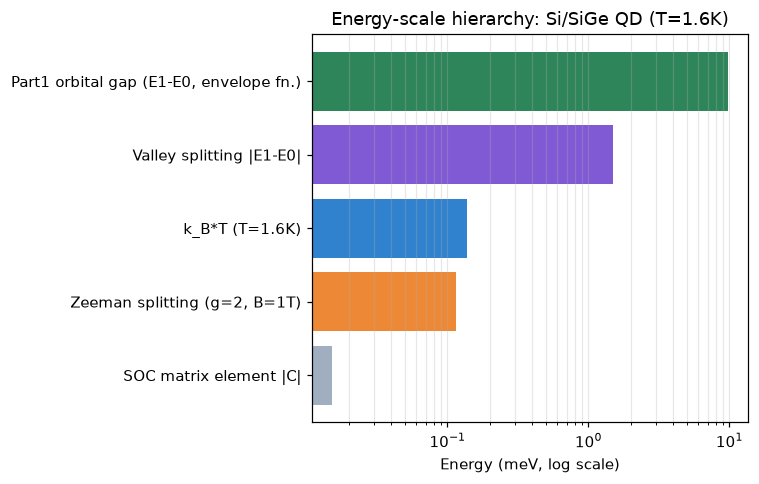

In [6]:
# [실험] 에너지 스케일 비교 막대그래프 (log scale)
fig, ax = plt.subplots(figsize=(7, 4.5))
order = energy_scale_df.sort_values("value_meV")
colors = ["#a0aec0", "#ed8936", "#3182ce", "#805ad5", "#2f855a"]
ax.barh(order["scale"], order["value_meV"], color=colors[:len(order)])
ax.set_xscale("log")
ax.set_xlabel("Energy (meV, log scale)")
ax.set_title("Energy-scale hierarchy: Si/SiGe QD (T=1.6K)")
ax.grid(axis="x", alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "04_energy_scale_hierarchy.png", dpi=160, bbox_inches="tight")
plt.show()

**해석:** valley splitting(~1.5 meV)은 열에너지(k_B*1.6K ~ 0.14 meV)보다
훨씬 크므로 이 온도에서 두 valley 상태는 열적으로 잘 분리되어 있습니다
(바닥 valley 상태만 populated). 동시에 Part 1의 orbital gap(~9.8 meV)보다는
작으므로, valley 자유도는 **바닥 orbital 상태 내부의 미세 구조**로 존재합니다
— 이는 스핀 큐비트로 사용하기 위한 바람직한 에너지 순서입니다(orbital >>
valley >> Zeeman이면 leakage 경로가 억제됨). SOC 행렬요소 `|C|`는 valley
splitting보다 약 2자리 정도 작아, valley-궤도-스핀 혼합에 의한 스핀 완화
경로가 상대적으로 약함을 시사합니다. (일반적으로 문헌에 보고되는 Si/SiGe
양자점의 valley splitting은 실험/시뮬레이션 조건에 따라 수십 ueV~수 meV
범위에 걸쳐 있으며, ~1.5 meV는 그 중간~상위권에 해당하는, 계면이 비교적
매끄러운 경우에 해당하는 값입니다. 구체적 문헌 수치는 인용하지 않고
일반적인 알려진 범위로만 언급합니다.)

## 5. 원자 구조 조성 분석 (`multiscale.xyz`)

전체 구조는 x,y in [-10,10]nm, z in [-50,-5]nm 범위에 지어졌으며, cap/buffer
층은 Si(0.7)/Ge(0.3) 랜덤 합금, 얇은 quantum well(약 3nm, rough Si/SiGe
계면 사이)은 순수 Si입니다. `.xyz` 파일의 원자 좌표는 **Angstrom** 단위입니다
(FEM 산출물의 nm 단위와 다름에 유의). 51MB 파일을 pandas로 직접 읽어
화학종 카운트를 raw 데이터에서 재계산합니다.

In [7]:
# [동작] xyz 파일 파싱 및 화학종 카운트
with open(FILE_XYZ) as f:
    n_atoms_header = int(f.readline().strip())

atoms_df = pd.read_csv(FILE_XYZ, sep=r"\s+", skiprows=2, names=["species", "x_A", "y_A", "z_A"])
print(f"xyz 헤더의 원자 수: {n_atoms_header:,}")
print(f"실제 파싱된 행 수 : {len(atoms_df):,}")

species_counts = atoms_df["species"].value_counts()
ge_fraction_total = species_counts.get("Ge", 0) / len(atoms_df)
species_df = pd.DataFrame({
    "species": species_counts.index,
    "count": species_counts.values,
    "fraction": species_counts.values / len(atoms_df),
})
display(species_df)
print(f"\n전체 구조 Ge 원자 분율: {ge_fraction_total:.4f}")

xyz 헤더의 원자 수: 896,337
실제 파싱된 행 수 : 896,337


,species,count,fraction
0,Si,644956,0.719546
1,Ge,251381,0.280454



전체 구조 Ge 원자 분율: 0.2805


### 명목 조성과의 비교

cap층(z: -5 -> ~-35nm, well_top 평균 기준) + buffer층(z: ~-38 -> -50nm)은
합금 조성 x=0.3, 순수 Si 우물(~-35 -> -38nm, 두께 ~3nm)은 Ge가 없습니다.
전체 z 범위 45nm 중 SiGe 합금 영역이 차지하는 부피 비율로 예상되는
전체 Ge 분율을 geometry로부터 역으로 계산해 raw 카운트와 비교합니다.

In [8]:
# [점검] 기하학적 예상치 vs 실제 카운트 비교
z_total_span = 45.0  # nm, [-50,-5]
z_well_span = 3.0  # nm, well_top(-35) ~ well_bot(-38) 평균 근사
sige_volume_fraction = (z_total_span - z_well_span) / z_total_span
expected_ge_fraction = sige_volume_fraction * 0.3

print(f"SiGe 합금 영역 부피 비율 (기하학적 추정): {sige_volume_fraction:.4f}")
print(f"예상 전체 Ge 분율 (추정 x=0.3 x 부피비): {expected_ge_fraction:.4f}")
print(f"실제 카운트된 Ge 분율                    : {ge_fraction_total:.4f}")
print(f"상대 차이                                : {abs(ge_fraction_total-expected_ge_fraction)/expected_ge_fraction*100:.1f} %")

SiGe 합금 영역 부피 비율 (기하학적 추정): 0.9333
예상 전체 Ge 분율 (추정 x=0.3 x 부피비): 0.2800
실제 카운트된 Ge 분율                    : 0.2805
상대 차이                                : 0.2 %


## 6. Tight-binding valley 상태 (`multiscale_TB_wf.vtu`) — 기하/화학종 분포 재검증

`multiscale_TB_wf.vtu`는 QD로 국한된 87,189개 원자에 대한 확률밀도
(`Probability density (ground state)`, `(1st excited state)`, `(2nd excited
state)`)와 각 원자가 Si/Ge인지를 나타내는 마스크(`Si`, `Ge`)를 담고 있습니다
(좌표 단위: **Angstrom**). 로그에 출력된 `analyze_dot` 기하 정보와 화학종
확률을 그대로 신뢰하지 않고, raw point data에서 직접 재계산해 교차검증합니다.

In [9]:
# [동작] TB_wf VTU 로드
tb_mesh = pv.read(FILE_TB_WF)
print(tb_mesh)
print("Point data arrays:", tb_mesh.array_names)

prob_gs = tb_mesh["Probability density (ground state)"]
prob_es = tb_mesh["Probability density (1st excited state)"]
ge_mask = tb_mesh["Ge"]
si_mask = tb_mesh["Si"]
coords_A = tb_mesh.points  # Angstrom

UnstructuredGrid (0x22535caae60)
  N Cells:    87189
  N Points:   87189
  X Bounds:   -7.948e+01, 7.956e+01
  Y Bounds:   -7.953e+01, 7.954e+01
  Z Bounds:   -3.992e+02, -3.306e+02
  N Arrays:   5
Point data arrays: ['Probability density (ground state)', 'Ge', 'Probability density (1st excited state)', 'Probability density (2nd excited state)', 'Si']


In [10]:
# [동작] 기하 정보(중심/표준편차/크기) 재계산
def weighted_geometry(prob, coords):
    w = prob / prob.sum()
    centroid = np.array([np.sum(w * coords[:, i]) for i in range(3)])
    var = np.array([np.sum(w * (coords[:, i] - centroid[i]) ** 2) for i in range(3)])
    std = np.sqrt(var)
    return centroid, std, 4.0 * std  # size = 4*std convention (Part1에서 검증됨)

centroid_gs, std_gs, size_gs = weighted_geometry(prob_gs, coords_A)
centroid_es, std_es, size_es = weighted_geometry(prob_es, coords_A)

# 로그에서 동일 수치 파싱 (nu_1 = ground, nu_2 = 1st excited)
m_geoms = re.findall(
    r"position:\s*\[([^\]]+)\]\s*A\s*\n\s*std:\s*\[([^\]]+)\]\s*A\s*\n\s*size:\s*\[([^\]]+)\]\s*A",
    log2_text,
)
log_pos_gs, log_std_gs, log_size_gs = [np.array([float(v) for v in g.split()]) for g in m_geoms[0]]
log_pos_es, log_std_es, log_size_es = [np.array([float(v) for v in g.split()]) for g in m_geoms[1]]

geom_compare_df = pd.DataFrame({
    "axis": ["x", "y", "z"] * 2,
    "state": ["ground (nu_1)"] * 3 + ["1st excited (nu_2)"] * 3,
    "recomputed_std_A": np.concatenate([std_gs, std_es]),
    "log_std_A": np.concatenate([log_std_gs, log_std_es]),
    "recomputed_size_A": np.concatenate([size_gs, size_es]),
    "log_size_A": np.concatenate([log_size_gs, log_size_es]),
})
display(geom_compare_df)

,axis,state,recomputed_std_A,log_std_A,recomputed_size_A,log_size_A
0,x,ground (nu_1),27.847337,27.847337,111.389350,111.389350
1,y,ground (nu_1),28.867010,28.867010,115.468039,115.468039
2,z,ground (nu_1),7.488179,7.488179,29.952717,29.952717
3,x,1st excited (nu_2),28.208409,28.208409,112.833634,112.833634
4,y,1st excited (nu_2),28.846067,28.846067,115.384269,115.384269
5,z,1st excited (nu_2),7.449361,7.449361,29.797445,29.797445


## 7. 화학종(Ge/Si) 확률 분포 독립 재계산

로그는 `nu_1.get_prob_on_chemical_species()`로 Ge~3.37%, Si~96.63%를
출력합니다. 여기서는 VTU의 원시 `Ge`/`Si` 마스크 배열과 확률밀도를 직접
곱해 합산하는 방식으로 동일한 수치를 독립적으로 재현합니다.

In [11]:
# [점검] Ge/Si 확률 가중합 - 로그값과 교차검증
def species_probability(prob, mask):
    return float(np.sum(prob * mask) / np.sum(prob))

ge_prob_gs = species_probability(prob_gs, ge_mask)
si_prob_gs = species_probability(prob_gs, si_mask)
ge_prob_es = species_probability(prob_es, ge_mask)
si_prob_es = species_probability(prob_es, si_mask)

m_species_blocks = re.findall(
    r"Probabilities of finding an electron on each chemical species\nGe:\s*([\d.]+)\nSi:\s*([\d.]+)",
    log2_text,
)
log_ge_gs, log_si_gs = float(m_species_blocks[0][0]), float(m_species_blocks[0][1])
log_ge_es, log_si_es = float(m_species_blocks[1][0]), float(m_species_blocks[1][1])

species_compare_df = pd.DataFrame({
    "state": ["ground (nu_1)", "1st excited (nu_2)"],
    "Ge_recomputed": [ge_prob_gs, ge_prob_es],
    "Ge_log": [log_ge_gs, log_ge_es],
    "Si_recomputed": [si_prob_gs, si_prob_es],
    "Si_log": [log_si_gs, log_si_es],
})
display(species_compare_df)

# 참고: 원자 개수 기준(가중치 없는) Ge 분율을 같은 QD 박스 내에서 비교
qd_box_mask = (
    (atoms_df["x_A"].abs() <= 80) & (atoms_df["y_A"].abs() <= 80) &
    (atoms_df["z_A"] >= -400) & (atoms_df["z_A"] <= -330)
)
ge_fraction_in_box_atomcount = (atoms_df.loc[qd_box_mask, "species"] == "Ge").mean()
print(f"\nQD 박스 내 '원자 개수' 기준 Ge 분율 (가중치 없음): {ge_fraction_in_box_atomcount:.4f}")
print(f"QD 박스 내 '전자확률 가중' Ge 분율 (ground state) : {ge_prob_gs:.4f}")
print("=> 전자는 순수 Si 우물 안에 대부분 머물기 때문에, 박스 안의 실제 원자 Ge 함량보다")
print("   전자가 실제로 '느끼는' Ge 분율이 훨씬 낮습니다 (장벽 침투 확률이 작음을 의미).")

,state,Ge_recomputed,Ge_log,Si_recomputed,Si_log
0,ground (nu_1),0.033682,0.033682,0.966318,0.966318
1,1st excited (nu_2),0.032417,0.032417,0.967583,0.967583



QD 박스 내 '원자 개수' 기준 Ge 분율 (가중치 없음): 0.1751
QD 박스 내 '전자확률 가중' Ge 분율 (ground state) : 0.0337
=> 전자는 순수 Si 우물 안에 대부분 머물기 때문에, 박스 안의 실제 원자 Ge 함량보다
   전자가 실제로 '느끼는' Ge 분율이 훨씬 낮습니다 (장벽 침투 확률이 작음을 의미).


## 8. Valley 상태의 z-방향 확률밀도 프로파일

ground(nu_1)과 1st excited(nu_2) valley 상태는 거의 동일한 envelope(같은
quantum well 안에 위치)를 갖지만, valley 위상 간섭 때문에 원자 스케일에서
미세하게 다른 분포를 가집니다. 두 상태의 z-방향 확률밀도(다른 축에 대해
적분한 marginal distribution)를 비교해 envelope가 거의 일치함을 직접 확인합니다.

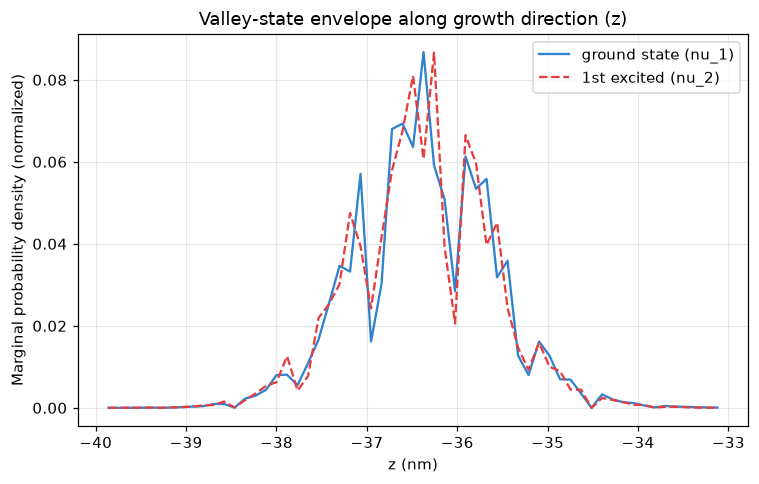

nu_1/nu_2 envelope overlap (marginal z-분포, histogram 기반): 0.8784
=> 두 valley 상태의 envelope는 거의 동일합니다 (같은 quantum well 안);
   차이는 원자 스케일 valley 위상 진동에서 오는 것으로, 이 z-히스토그램의
   해상도로는 직접 보이지 않습니다 (valley splitting의 기원은 계면에서의
   급격한 포텐셜 변화에 대한 밸리 간 산란임).


In [12]:
# [실험] z-방향 확률밀도 프로파일 (ground vs 1st excited)
z_A = coords_A[:, 2]
z_bins = np.linspace(z_A.min(), z_A.max(), 60)
z_centers = 0.5 * (z_bins[1:] + z_bins[:-1])

hist_gs, _ = np.histogram(z_A, bins=z_bins, weights=prob_gs)
hist_es, _ = np.histogram(z_A, bins=z_bins, weights=prob_es)
hist_gs /= hist_gs.sum()
hist_es /= hist_es.sum()

plt.figure(figsize=(7, 4.5))
plt.plot(z_centers / 10.0, hist_gs, label="ground state (nu_1)", color="#3182ce")
plt.plot(z_centers / 10.0, hist_es, label="1st excited (nu_2)", color="#e53e3e", linestyle="--")
plt.xlabel("z (nm)")
plt.ylabel("Marginal probability density (normalized)")
plt.title("Valley-state envelope along growth direction (z)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "08_valley_z_profile.png", dpi=160, bbox_inches="tight")
plt.show()

overlap = np.sum(np.minimum(hist_gs, hist_es))
print(f"nu_1/nu_2 envelope overlap (marginal z-분포, histogram 기반): {overlap:.4f}")
print("=> 두 valley 상태의 envelope는 거의 동일합니다 (같은 quantum well 안);")
print("   차이는 원자 스케일 valley 위상 진동에서 오는 것으로, 이 z-히스토그램의")
print("   해상도로는 직접 보이지 않습니다 (valley splitting의 기원은 계면에서의")
print("   급격한 포텐셜 변화에 대한 밸리 간 산란임).")

## 9. 참고: band structure 및 계면 거칠기 그림 (이미 렌더링됨)

`multiscale_bs_Si.png`/`multiscale_bs_Ge.png`는 Si/Ge 벌크 밴드구조를,
`multiscale_rough_2d.png`/`multiscale_rough_3d.png`는 quantum well 상부/하부
계면의 self-affine 거칠기(Hurst=0.3, RMS=0.5nm)를 보여줍니다. 이 이미지들은
이미 튜토리얼에서 렌더링되어 있으므로 재생성하지 않고, 파일 존재만 inventory
단계(섹션 1)에서 확인했습니다. 계면 거칠기는 Section 7-8에서 다룬 valley
splitting의 계면 민감도(장벽 침투 확률, envelope 미세구조)와 직접 연결되는
물리적 원인입니다.

## 10. 최종 요약

In [13]:
# [점검] 핵심 결과 요약
print("=" * 88)
print("QTCAD 01. SiGe One QD — PART 2 ANALYSIS SUMMARY")
print("=" * 88)
print(f"Valley splitting (E1-E0)            : {valley_splitting_eV*1000:.5f} meV  ({valley_splitting_GHz:.2f} GHz)")
print(f"SOC matrix element |C|              : {abs(C_eV)*1000:.6f} meV")
print(f"Derivative matrix element |D|       : {abs(D_eV_per_V)*1e6:.4f} ueV/V")
print(f"|C| / valley splitting              : {abs(C_eV)/abs(valley_splitting_eV):.2e}")
print(f"Valley splitting / k_B*T(1.6K)      : {abs(valley_splitting_eV)/kT_eV:.1f}x")
print(f"Valley splitting / Part1 orbital gap: {abs(valley_splitting_eV)/orbital_gap_eV:.3f}")
print(f"D 단위 검증 (raw D/e vs 로그 eV/V)  : {np.isclose(D_eV_per_V.real, D_logged_eV_per_V)}")
print(f"전체 구조 원자 수 (xyz 헤더)        : {n_atoms_header:,}")
print(f"전체 구조 Ge 분율 (실측)            : {ge_fraction_total:.4f}  (기하학적 예상: {expected_ge_fraction:.4f})")
print(f"TB_wf.vtu 원자 수 (QD 국한)         : {tb_mesh.n_points:,}")
print(f"Ge 확률 (ground state, 전자확률 가중): {ge_prob_gs:.4f}  (로그값: {log_ge_gs:.4f})")
print(f"Analysis export directory           : {EXPORT_DIR}")
print("=" * 88)

QTCAD 01. SiGe One QD — PART 2 ANALYSIS SUMMARY
Valley splitting (E1-E0)            : 1.48551 meV  (359.20 GHz)
SOC matrix element |C|              : 0.015128 meV
Derivative matrix element |D|       : 6.1197 ueV/V
|C| / valley splitting              : 1.02e-02
Valley splitting / k_B*T(1.6K)      : 10.8x
Valley splitting / Part1 orbital gap: 0.151
D 단위 검증 (raw D/e vs 로그 eV/V)  : True
전체 구조 원자 수 (xyz 헤더)        : 896,337
전체 구조 Ge 분율 (실측)            : 0.2805  (기하학적 예상: 0.2800)
TB_wf.vtu 원자 수 (QD 국한)         : 87,189
Ge 확률 (ground state, 전자확률 가중): 0.0337  (로그값: 0.0337)
Analysis export directory           : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\01. SiGe One QD_part.1\Reference\analysis_exports


## 해석 주의사항

- `multiscale_params.txt`의 `valley_splitting`, `C`, `D`는 **raw SI 단위**
  (Joule, Joule/V)로 저장된 값이며, `multiscale_2.py`가 print할 때만
  `/ ct.e`로 eV(/V) 변환을 수행합니다. 이 노트북은 그 변환을 직접 재현했습니다.
- **der/D 단위 (Part 1과 연결된 핵심 발견):** `D`(raw)를 `e`로 나눈 값은
  `multiscale_2_run3.log`에 스크립트 자신이 출력한 "eV/V" 값과 정확히
  일치합니다. 이는 Part 1에서 독립적으로 확인한 "`multiscale_der.hdf5`의
  raw 배열은 SI Joule/V이고, `/e`하면 eV/V"라는 결론과 완전히 일치하는
  교차검증입니다. 튜토리얼의 `multiscale_der_slice.png` 컬러바 라벨
  ("meV/V")은 실제로는 **eV/V**여야 하는 1000배 라벨링 오류입니다
  (자세한 내용은 Part 1 노트북 섹션 7-8 참고).
- `C`, `D`는 복소수 행렬요소입니다. 물리적으로 의미 있는 것은 크기(절댓값)이며,
  위상은 valley 위상(`valley_phase`, 로그에 별도로 출력됨: 2.2296 rad)과
  관련된 간섭 정보를 담고 있어 rate 계산에는 직접 쓰이지 않습니다.
- 길이 단위: `multiscale.xyz`, `multiscale_TB_wf.vtu`는 **Angstrom**,
  Part 1의 FEM 산출물은 **nm**입니다. 두 데이터를 함께 다룰 때 10배 환산에
  주의해야 합니다.
- 섹션 4의 "전형적 Zeeman 분리"와 valley splitting 문헌값 비교는 **일반
  지식에 기반한 대략적 크기 비교**이며, 특정 논문의 실측값을 인용한 것이
  아닙니다. 실제 valley splitting은 계면 거칠기, 우물 두께, 전기장 등에 따라
  같은 소자에서도 수십 ueV ~ 수 meV까지 크게 변할 수 있습니다.
- 섹션 5의 "기하학적 예상 Ge 분율"은 `well_top`/`well_bot`의 *평균* 위치만
  사용한 근사치이며, 실제 계면은 RMS 0.5nm의 거칠기를 가지므로 정확히
  일치하지 않을 수 있습니다.